# Multi-Epoch Geometry Recovery from SRP

Recover 7 geometry/material parameters of a satellite using trajectory observations from multiple epochs spanning a year.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from pathlib import Path

import base, designer, nn, integrator
from utils import load_trajectory, sample_moonsun_cubic

jax.config.update("jax_enable_x64", True)
plt.rcParams['figure.figsize'] = (12, 5)
PLOT_DIR = base.PROJECT_ROOT / 'plots' / 'box_wing_experiments'
PLOT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
OBJECT_NAME = 'gps2f_boxwing/gps2f_boxwing'
DESIGN_NAME = 'box_wing_geometry_material'
SCALE_MIN, SCALE_MAX = 0.5, 2.0

geometry_specs = [
    designer.make_box_scale_spec('S_Arr_R_Array_mat', scale_axis='x', scale_min=SCALE_MIN, scale_max=SCALE_MAX,
                                  linked_groups=['S_Arr_L_Array_mat', 'S_Arr_R_Mesh', 'S_Arr_L_Mesh']),
    designer.make_box_scale_spec('S_Arr_R_Array_mat', scale_axis='y', scale_min=SCALE_MIN, scale_max=SCALE_MAX,
                                  linked_groups=['S_Arr_L_Array_mat', 'S_Arr_R_Mesh', 'S_Arr_L_Mesh']),
    designer.make_box_scale_spec('BUS_Bus_mat', scale_axis='x', scale_min=SCALE_MIN, scale_max=SCALE_MAX,
                                  linked_groups=['BUS_Mesh']),
    designer.make_box_scale_spec('BUS_Bus_mat', scale_axis='z', scale_min=SCALE_MIN, scale_max=SCALE_MAX,
                                  linked_groups=['BUS_Mesh']),
    designer.make_box_scale_spec('BUS_Bus_mat', scale_axis='y', scale_min=SCALE_MIN, scale_max=SCALE_MAX,
                                  linked_groups=['BUS_Mesh']),
]

material_specs = [
    designer.make_material_spec('S_Arr_R_Array_mat', reflectance_min=0.0, reflectance_max=1.0,
                                 linked_groups=['S_Arr_L_Array_mat', 'S_Arr_R_Mesh', 'S_Arr_L_Mesh']),
    designer.make_material_spec('BUS_Bus_mat', reflectance_min=0.0, reflectance_max=1.0,
                                 linked_groups=['BUS_Mesh']),
]

box_wing_design = designer.build_box_wing_design(OBJECT_NAME, geometry_specs, material_specs)
designer.my_design = box_wing_design
PARAM_NAMES = ['panel_w', 'panel_h', 'bus_w', 'bus_h', 'bus_d', 'panel_alb', 'bus_refl']
TRUE_PARAMS = jnp.array([0.6, 0.4, 0.55, 0.45, 0.5, 0.65, 0.35], dtype=jnp.float64)

In [3]:
import raytracing, srp_simulation, estimation
from pathlib import Path

LOAD_PRECOMPUTED = True
LOAD_PRETRAINED = True
SUN_GRID = (90, 180)
force_path = base.get_force_path(OBJECT_NAME, DESIGN_NAME)

if LOAD_PRECOMPUTED:
    for s in ['_force', '_torque', '_directions', '_parameters']:
        np.load(force_path + s + '.npy')
    print('Loaded precomputed force/torque maps')
else:
    mesh = raytracing.load_mesh(base.get_mesh_name(OBJECT_NAME))
    force, torque, dirs, params = srp_simulation.build_force_map(
        SUN_GRID, 10_000, estimation.estimate_backward, mesh, box_wing_design, profile_interval=1000)
    for s, a in [('_force', force), ('_torque', torque), ('_directions', dirs), ('_parameters', params)]:
        np.save(force_path + s + '.npy', np.array(a).reshape(-1, 3 if 'param' not in s else box_wing_design.shape))

nn.train_combined_proxy(
    OBJECT_NAME, DESIGN_NAME, SUN_GRID,
    feature_suffix='_parameters.npy', direction_suffix='_directions.npy',
    force_suffix='_force.npy', torque_suffix='_torque.npy',
    weight_prefix='combined', checkpoint_name='combined_training_checkpoint.pkl',
    load_pretrained=LOAD_PRETRAINED, num_hidden_layers=5, hidden_width=192, max_steps=100_000,
    log_every=1000, diag_every=10000)

# Load NN proxy
nn_dir = Path(base.get_nn_weight_path(OBJECT_NAME, DESIGN_NAME))
bundle = {k: tuple(jnp.asarray(v, dtype=jnp.float64) for v in nn.load_nn_parameters(nn_dir / f'combined_{s}.bin'))
          for k, s in [('params', 'parameters'), ('feat', 'ray_stats'), ('tgt', 'target_stats')]}

SC_MASS = 500.0
SC_AREA = 25.0

def eval_proxy(sun_dir_body, design_params):
    feat = jnp.concatenate([sun_dir_body, design_params])
    w = nn.whiten_with_stats(feat, bundle['feat'])
    pred = nn.unwhiten(0.5 * (nn.mlp(w, bundle['params']) + 1.0), bundle['tgt'])
    return SC_AREA * pred[:3]

/Users/charlesc/anaconda3/envs/photonsxforce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded precomputed force/torque maps


In [4]:
trajectory = load_trajectory(base.drive_path + 'trajectories/gps08.csv', limit=None)
sun_positions = jnp.asarray(trajectory.sun, dtype=jnp.float64)
sun_times = jnp.asarray(trajectory.time, dtype=jnp.float64)

N_ORBITS = 12
STEP_SIZE_S = 60.0
ORBIT_HOURS = 6.0
ORBIT_STEPS = int(ORBIT_HOURS * 3600 / STEP_SIZE_S)

RAAN_OFFSETS_DEG = np.linspace(0, 330, N_ORBITS)
INCLINATION_OFFSETS_DEG = np.array([0, 5, -5, 10, -10, 3, -3, 7, -7, 2, -8, 8])[:N_ORBITS]
ECCENTRICITY_OFFSETS = np.array([0.0, 0.02, -0.01, 0.03, -0.02, 0.01, -0.015, 0.025, -0.005, 0.015, -0.025, 0.005])[:N_ORBITS]
EPOCH_TIME_OFFSETS_DAYS = np.linspace(0, 180, N_ORBITS)

def modify_eccentricity(pos, vel, delta_ecc, mu=3.986004418e14):
    r_hat = pos / np.linalg.norm(pos)
    h_hat = np.cross(pos, vel); h_hat = h_hat / np.linalg.norm(h_hat)
    t_hat = np.cross(h_hat, r_hat)
    return np.dot(vel, r_hat) * r_hat + np.dot(vel, t_hat) * (1.0 + delta_ecc * 0.15) * t_hat

def modify_inclination(pos, vel, delta_inc_rad):
    c, s = np.cos(delta_inc_rad), np.sin(delta_inc_rad)
    R = np.array([[1,0,0],[0,c,-s],[0,s,c]])
    return R @ pos, R @ vel

np.random.seed(42)
orbit_configs = []
for i in range(N_ORBITS):
    idx = int(EPOCH_TIME_OFFSETS_DAYS[i] * 24) % len(trajectory.time)
    pos = np.array(trajectory.position[idx])
    vel = modify_eccentricity(pos, np.array(trajectory.velocity[idx]), ECCENTRICITY_OFFSETS[i])
    pos, vel = modify_inclination(pos, vel, np.deg2rad(INCLINATION_OFFSETS_DEG[i]))
    c, s = np.cos(np.deg2rad(RAAN_OFFSETS_DEG[i])), np.sin(np.deg2rad(RAAN_OFFSETS_DEG[i]))
    R = np.array([[c,-s,0],[s,c,0],[0,0,1]])
    orbit_configs.append({'pos0': R @ pos, 'vel0': R @ vel, 't0': float(trajectory.time[idx]),
                          'raan_deg': RAAN_OFFSETS_DEG[i], 'inc_offset_deg': INCLINATION_OFFSETS_DEG[i],
                          'ecc_offset': ECCENTRICITY_OFFSETS[i], 'epoch_day': EPOCH_TIME_OFFSETS_DAYS[i]})

ORBIT_POS0 = jnp.array([c['pos0'] for c in orbit_configs])
ORBIT_VEL0 = jnp.array([c['vel0'] for c in orbit_configs])
ORBIT_T0 = jnp.array([c['t0'] for c in orbit_configs])

def nadir_pointing(position, velocity):
    nadir = -position / jnp.linalg.norm(position)
    v_hat = velocity / jnp.linalg.norm(velocity)
    ct = jnp.cross(nadir, v_hat); ct = ct / jnp.linalg.norm(ct)
    at = jnp.cross(ct, nadir); at = at / jnp.linalg.norm(at)
    return jnp.column_stack([at, ct, -nadir])

def build_srp_provider(design_params):
    design_params = jnp.asarray(design_params, dtype=jnp.float64)
    def provider(position, velocity, time):
        sun_pos = sample_moonsun_cubic(time, sun_positions, sun_times)
        sun_dir = (sun_pos - position) / jnp.maximum(jnp.linalg.norm(sun_pos - position), 1e-12)
        R = nadir_pointing(position, velocity)
        return R @ eval_proxy(R.T @ sun_dir, design_params) / SC_MASS
    return provider

def dynamics(state, time, srp_provider):
    pos, vel = state
    return (vel, -3.986004418e14 * pos / jnp.linalg.norm(pos)**3 + srp_provider(pos, vel, time))

def simulate_orbit(design_params, pos0, vel0, t0):
    provider = build_srp_provider(design_params)
    dt = STEP_SIZE_S
    def step(carry, time):
        return integrator.integrate_rk4(carry, time, dynamics, provider, dt), carry
    final, hist = jax.lax.scan(step, (pos0, vel0), t0 + dt * jnp.arange(ORBIT_STEPS))
    return (jnp.concatenate([hist[0], final[0][None]], axis=0),
            jnp.concatenate([hist[1], final[1][None]], axis=0))

def simulate_all_orbits(design_params):
    all_pos, all_vel = jax.vmap(lambda p, v, t: simulate_orbit(design_params, p, v, t))(ORBIT_POS0, ORBIT_VEL0, ORBIT_T0)
    return all_pos.reshape(-1, 3), all_vel.reshape(-1, 3)

print(f'{N_ORBITS} orbits, {ORBIT_STEPS} steps each, {ORBIT_HOURS}h per orbit')

12 orbits, 360 steps each, 6.0h per orbit


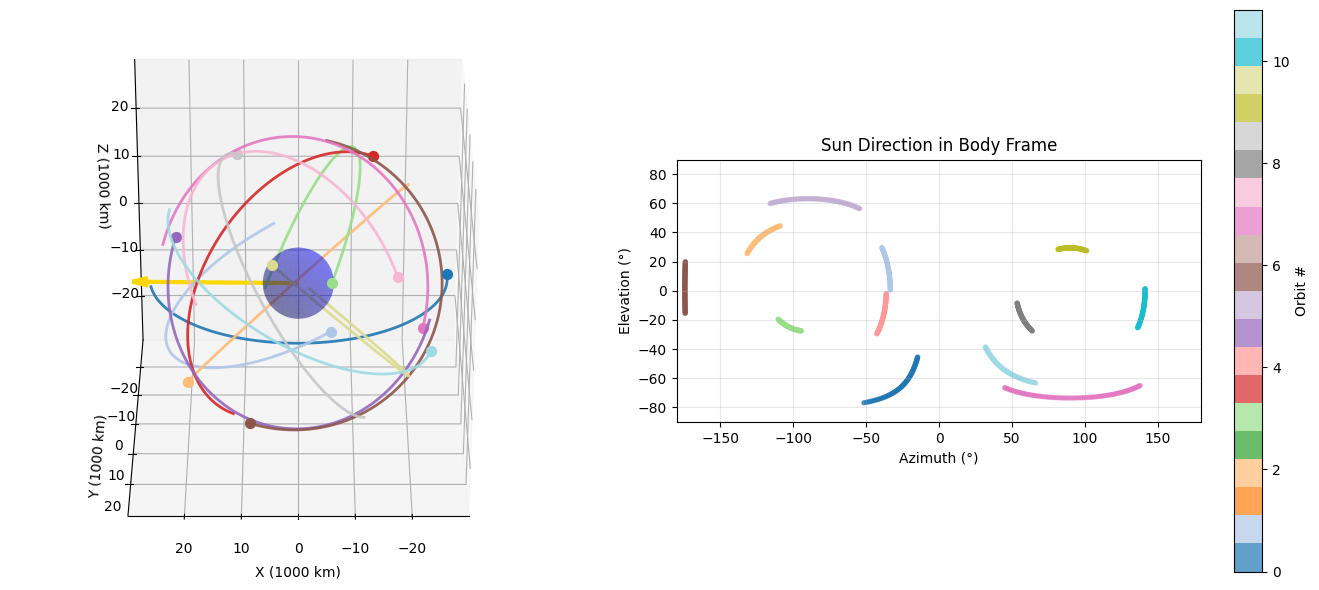


Sun direction coverage: Az=[-174.3°, 141.3°], El=[-76.8°, 63.2°]


In [5]:
# Visualize orbits in inertial space and sun direction coverage

fig = plt.figure(figsize=(14, 6))

# 3D orbit visualization in inertial frame
ax1 = fig.add_subplot(121, projection='3d')

# Plot Earth (scaled to match orbit coordinates)
u_sphere = np.linspace(0, 2 * np.pi, 50)
v_sphere = np.linspace(0, np.pi, 50)
R_EARTH = 6.371e6
orbit_scale = 1e-6  # Convert meters to 1000 km

x_earth = R_EARTH * orbit_scale * np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_earth = R_EARTH * orbit_scale * np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_earth = R_EARTH * orbit_scale * np.outer(np.ones(np.size(u_sphere)), np.cos(v_sphere))
ax1.plot_surface(x_earth, y_earth, z_earth, alpha=0.3, color='blue', zorder=1)

# Use tab20 colormap for better distinction between 12 orbits
colors_orbit = plt.cm.tab20(np.linspace(0, 0.95, N_ORBITS))

# Propagate and plot each orbit
all_orbit_positions = []
for i, cfg in enumerate(orbit_configs):
    pos = cfg['pos0'].copy()
    vel = cfg['vel0'].copy()
    mu = 3.986004418e14
    dt = 300
    positions = [pos.copy()]
    for _ in range(72):
        r = np.linalg.norm(pos)
        acc = -mu * pos / r**3
        vel = vel + acc * dt
        pos = pos + vel * dt
        positions.append(pos.copy())
    positions = np.array(positions)
    all_orbit_positions.append(positions)
    ax1.plot(positions[:, 0] * orbit_scale, positions[:, 1] * orbit_scale, 
             positions[:, 2] * orbit_scale, color=colors_orbit[i], linewidth=2, alpha=0.9, zorder=10)
    ax1.scatter(cfg['pos0'][0] * orbit_scale, cfg['pos0'][1] * orbit_scale, 
                cfg['pos0'][2] * orbit_scale, color=colors_orbit[i], s=50, marker='o', zorder=11)

# Sun direction arrow
sun_sample_idx = int(len(trajectory.sun) / 2)
sun_dir = np.array(trajectory.sun[sun_sample_idx])
sun_dir = sun_dir / np.linalg.norm(sun_dir)
sun_scale = 30  # Scale for arrow in 1000 km units
ax1.quiver(0, 0, 0, sun_dir[0]*sun_scale, sun_dir[1]*sun_scale, sun_dir[2]*sun_scale,
           color='gold', linewidth=3, arrow_length_ratio=0.1, zorder=12)

ax1.set_xlabel('X (1000 km)')
ax1.set_ylabel('Y (1000 km)')
ax1.set_zlabel('Z (1000 km)')
# ax1.set_title('12 Orbits in Inertial Frame')

# Set axis limits to show full orbits with 1:1:1 aspect ratio
orbit_radius = np.max([np.linalg.norm(pos, axis=1).max() for pos in all_orbit_positions]) * orbit_scale
lim = orbit_radius * 1.1
ax1.set_xlim(-lim, lim)
ax1.set_ylim(-lim, lim)
ax1.set_zlim(-lim, lim)
ax1.set_box_aspect([1, 1, 1])  # Equal aspect ratio
ax1.view_init(elev=30, azim=90)  # Rotate 90° anti-clockwise about z-axis

# Collect sun directions in body frame
sun_dirs_body = []
orbit_labels = []
for orbit_idx in range(N_ORBITS):
    cfg = orbit_configs[orbit_idx]
    pos, vel, t = cfg['pos0'].copy(), cfg['vel0'].copy(), cfg['t0']
    mu, dt = 3.986004418e14, STEP_SIZE_S
    for step in range(0, ORBIT_STEPS, 5):
        sun_pos = np.array(sample_moonsun_cubic(t, sun_positions, sun_times))
        sun_vec = sun_pos - pos
        sun_dir_inertial = sun_vec / np.linalg.norm(sun_vec)
        R_body = np.array(nadir_pointing(jnp.array(pos), jnp.array(vel)))
        sun_dir_body = R_body.T @ sun_dir_inertial
        sun_dirs_body.append(sun_dir_body)
        orbit_labels.append(orbit_idx)
        r = np.linalg.norm(pos)
        acc = -mu * pos / r**3
        vel = vel + acc * dt
        pos = pos + vel * dt
        t = t + dt

sun_dirs_body = np.array(sun_dirs_body)
orbit_labels = np.array(orbit_labels)
az = np.rad2deg(np.arctan2(sun_dirs_body[:, 1], sun_dirs_body[:, 0]))
el = np.rad2deg(np.arcsin(np.clip(sun_dirs_body[:, 2], -1, 1)))

# Azimuth-Elevation plot
ax2 = fig.add_subplot(122)
sc = ax2.scatter(az, el, c=orbit_labels, cmap='tab20', s=8, alpha=0.7, vmin=0, vmax=N_ORBITS-1)
ax2.set_xlabel('Azimuth (°)')
ax2.set_ylabel('Elevation (°)')
ax2.set_xlim(-180, 180)
ax2.set_ylim(-90, 90)
ax2.set_title('Sun Direction in Body Frame')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')  # Equal aspect for az/el plot
plt.colorbar(sc, ax=ax2, label='Orbit #', ticks=range(0, N_ORBITS, 2))

fig.tight_layout()
fig.savefig(str(base.PROJECT_ROOT / 'plots/box_wing_experiments/orbits_and_sun_coverage.svg'), bbox_inches='tight')
plt.show()

print(f"\nSun direction coverage: Az=[{az.min():.1f}°, {az.max():.1f}°], El=[{el.min():.1f}°, {el.max():.1f}°]")

In [6]:
true_pos_all, true_vel_all = simulate_all_orbits(TRUE_PARAMS)
print(f"Ground truth: {true_pos_all.shape[0]} points ({N_ORBITS} orbits × {ORBIT_STEPS+1} steps)")

Ground truth: 4332 points (12 orbits × 361 steps)


In [7]:
SRP_ACC_SCALE = 1e-7
T_SEC = ORBIT_HOURS * 3600
DELTA_V_SCALE = SRP_ACC_SCALE * T_SEC
DELTA_X_SCALE = 0.5 * SRP_ACC_SCALE * T_SEC**2
LOSS_SCALE = 1000.0

def loss_fn(params):
    pred_pos, pred_vel = simulate_all_orbits(params)
    pos_err = (pred_pos - true_pos_all) / DELTA_X_SCALE
    vel_err = (pred_vel - true_vel_all) / DELTA_V_SCALE
    return LOSS_SCALE * (jnp.mean(pos_err**2) + jnp.mean(vel_err**2))

loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))
loss_true = loss_fn(TRUE_PARAMS)
loss_wrong = loss_fn(jnp.full(7, 0.5))
print(f"Loss at TRUE: {float(loss_true):.2e}, Loss at 0.5: {float(loss_wrong):.4f}")

Loss at TRUE: 0.00e+00, Loss at 0.5: 2.9182


In [8]:
N_ITERS = 200
np.random.seed(42)
params = jnp.array(np.random.uniform(0.1, 0.9, 7))
schedule = optax.cosine_decay_schedule(init_value=0.1, decay_steps=N_ITERS, alpha=0.01)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(learning_rate=schedule))
opt_state = optimizer.init(params)

best_loss, best_params = float('inf'), params.copy()
loss_trace = []
param_trace = [np.array(params)]
trace_iters = [0]

for it in range(N_ITERS):
    loss_val, grads = loss_and_grad(params)
    loss_trace.append(float(loss_val))
    if float(loss_val) < best_loss:
        best_loss = float(loss_val)
        best_params = params.copy()
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    if (it + 1) % 10 == 0:
        param_trace.append(np.array(params))
        trace_iters.append(it + 1)
    if it % 50 == 0 or it == N_ITERS - 1:
        print(f"iter={it:03d} loss={loss_val:.6f}")

param_trace = np.array(param_trace)
recovered = np.array(best_params)
true_arr = np.array(TRUE_PARAMS)
errors = np.abs(recovered - true_arr) / true_arr * 100

print(f"\n{'Param':<10} {'True':>7} {'Recov':>7} {'Err%':>7}")
print("-" * 35)
for i, name in enumerate(PARAM_NAMES):
    print(f"{name:<10} {true_arr[i]:>7.3f} {recovered[i]:>7.3f} {errors[i]:>6.1f}%")
print("-" * 35)
print(f"{'MEAN':<10} {'':>7} {'':>7} {np.mean(errors):>6.1f}%")

iter=000 loss=22.194409


iter=050 loss=0.015920


iter=100 loss=0.000023


iter=150 loss=0.000000


iter=199 loss=0.000000

Param         True   Recov    Err%
-----------------------------------
panel_w      0.600   0.600    0.0%
panel_h      0.400   0.400    0.0%
bus_w        0.550   0.550    0.0%
bus_h        0.450   0.450    0.0%
bus_d        0.500   0.500    0.0%
panel_alb    0.650   0.650    0.0%
bus_refl     0.350   0.350    0.0%
-----------------------------------
MEAN                          0.0%


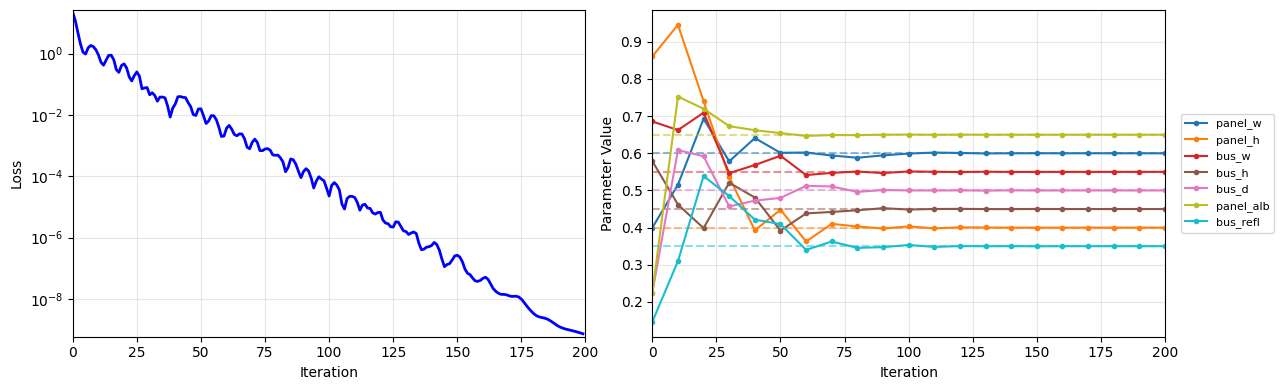

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].semilogy(loss_trace, 'b-', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

colors = plt.cm.tab10(np.linspace(0, 1, 7))
for i, name in enumerate(PARAM_NAMES):
    axes[1].plot(trace_iters, param_trace[:, i], '-o', color=colors[i], label=name, markersize=3)
    axes[1].axhline(y=true_arr[i], color=colors[i], linestyle='--', alpha=0.5)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Parameter Value')
axes[1].grid(True, alpha=0.3)

trace_iters_arr = np.asarray(trace_iters)
axes[0].set_xlim(trace_iters_arr.min(), trace_iters_arr.max())
axes[1].set_xlim(trace_iters_arr.min(), trace_iters_arr.max())

loss_arr = np.asarray(loss_trace)
positive_losses = loss_arr[loss_arr > 0]
if positive_losses.size:
    loss_min = positive_losses.min()
    loss_max = positive_losses.max()
    axes[0].set_ylim(loss_min * 0.8, loss_max * 1.2)

param_min = min(param_trace.min(), true_arr.min())
param_max = max(param_trace.max(), true_arr.max())
pad = 0.05 * (param_max - param_min) if param_max > param_min else 0.1
axes[1].set_ylim(param_min - pad, param_max + pad)

axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
fig.tight_layout()
fig.subplots_adjust(right=0.78)
fig.savefig(str(base.PROJECT_ROOT / 'plots/box_wing_experiments/params_estimation.svg'), bbox_inches='tight')